# Linear Regression on Bike Sharing Data

<center><img src="https://miro.medium.com/v2/resize:fit:996/1*ATlagc9XVjU6wu9z7CIVTQ.jpeg" width=500 height=300/></center>

Bike sharing systems are a means of renting bicycles where the process of obtaining membership, rental, and bike return is automated via a network of kiosk locations throughout a city. Using these systems, people are able rent a bike from a one location and return it to a different place on an as-needed basis. Currently, there are over 500 bike-sharing programs around the world.

The data generated by these systems makes them attractive for researchers because the duration of travel, departure location, arrival location, and time elapsed is explicitly recorded. Bike sharing systems therefore function as a sensor network, which can be used for studying mobility in a city. In this competition, participants are asked to combine historical usage patterns with weather data in order to forecast bike rental demand in the Capital Bikeshare program in Washington, D.C.

https://www.kaggle.com/competitions/bike-sharing-demand/overview

Unlocking the patterns hidden within this rich dataset through regression analysis is like discovering the city's pulse—a chance to reveal how factors like weather, season, and daily routines influence bike demand.

## Section 1: Data Information

You are provided hourly rental data spanning two years. For this competition, the training set is comprised of the first 19 days of each month, while the test set is the 20th to the end of the month. You must predict the total count of bikes rented during each hour covered by the test set, using only information available prior to the rental period.

####Data Fields
- **datetime** - hourly date + timestamp  
- **season** -  1 = spring, 2 = summer, 3 = fall, 4 = winter
- **holiday**- whether the day is considered a holiday
- **workingday** - whether the day is neither a weekend nor holiday
- **weather** -
  - 1: Clear, Few clouds, Partly cloudy, Partly cloudy
  - 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
  - 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
  - 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
- **temp**- temperature in Celsius
- **atemp** - "feels like" temperature in Celsius
- **humidity** - relative humidity
- **windspeed** - wind speed
- **casual** - number of non-registered user rentals initiated
- **registered** - number of registered user rentals initiated
- **count** - number of total rentals




## Section 2: Run this code
*Note: These concepts are already covered in previous class.
The explanation for the same is available in the pre-class video.*

In [2]:
# Import the necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
pd.set_option('display.max_colwidth', None)



# Load the data
data = pd.read_csv("BikeDataset.csv", header=0)

# Data Pre-processing
data["datetime"] = pd.to_datetime(data["datetime"])
data["hour"] = data["datetime"].dt.hour
data["day_of_week"] = data["datetime"].dt.dayofweek
data["month"] = data["datetime"].dt.month
data["year"] = data["datetime"].dt.year
data["datetime"].dt.day.value_counts().sort_index()
data.drop(columns=["datetime"], inplace=True)

## Section 3: Simple Linear Regression
Simple linear regression is a statistical method used to understand the relationship between two variables: one independent variable (predictor) and one dependent variable (outcome). It finds the best-fitting straight line (called the regression line) through the data points, which can then be used to predict the dependent variable based on the independent variable. In essence, it's about drawing a line that best explains how changes in one variable are associated with changes in another.

<center><img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRtw-eyPcWmDPv8ApYYZO4ZkL_kiE_XMk4Syw&s"/></center>

In [4]:
# View the data
data.head(2)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,hour,day_of_week,month,year
0,1,0,0,1,9.84,14.395,81,0.0,3.0,13.0,16.0,0,5,1,2011
1,1,0,0,1,9.02,13.635,80,0.0,8.0,32.0,40.0,1,5,1,2011


`count` is the target variable - the variable whose values will be predicted.

Let's find out which of the independent variables influence `count` the most.

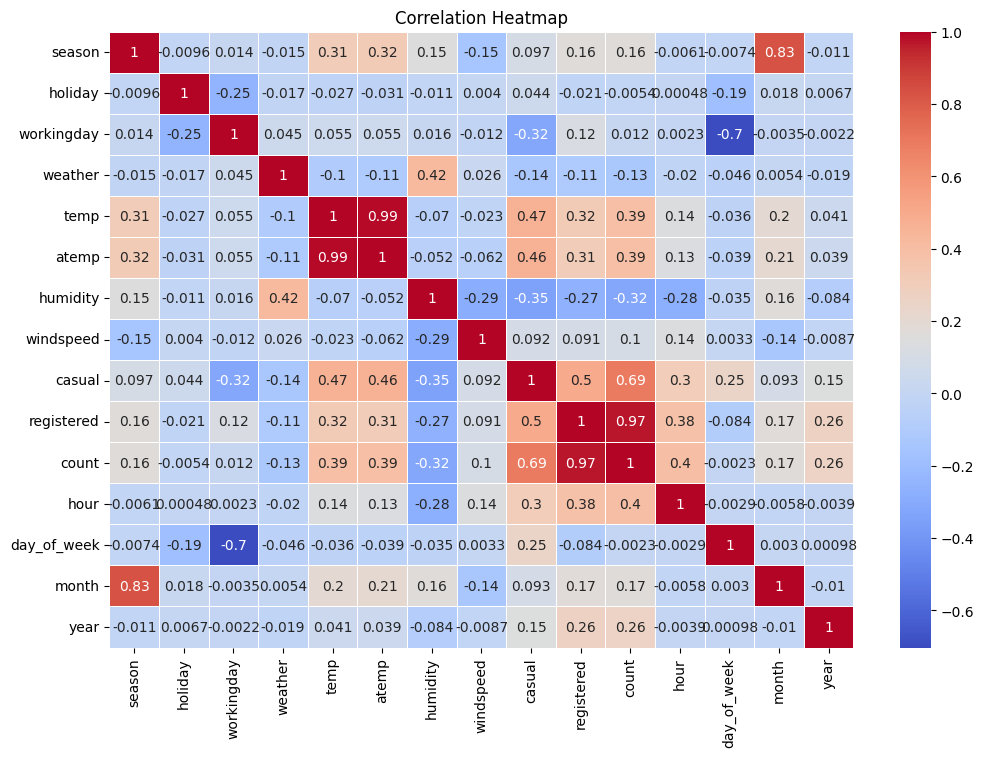

In [5]:
# Find out the correlation of the variables with 'count'
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', linewidths=.5)
plt.title('Correlation Heatmap')
plt.show()

Observations:
- Casual + Registered = Count. So, these variables are highly correlated.
- `temp` has a good correlation with `count`.

Let's try to fit a simple linear regression model to understand how `temp` influences `count`.


In [6]:
# Check the data
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   season       17379 non-null  int64  
 1   holiday      17379 non-null  int64  
 2   workingday   17379 non-null  int64  
 3   weather      17379 non-null  int64  
 4   temp         17379 non-null  float64
 5   atemp        17379 non-null  float64
 6   humidity     17379 non-null  int64  
 7   windspeed    17379 non-null  float64
 8   casual       10886 non-null  float64
 9   registered   10886 non-null  float64
 10  count        10886 non-null  float64
 11  hour         17379 non-null  int32  
 12  day_of_week  17379 non-null  int32  
 13  month        17379 non-null  int32  
 14  year         17379 non-null  int32  
dtypes: float64(6), int32(4), int64(5)
memory usage: 1.7 MB


#### Observation:
There are missing values in the target variable `count`. So, those rows are not useful for the analysis. So, let's drop them.

In [ ]:
# Remove the rows with missing values
data= data.dropna()
data.isna().sum()

#### Observation:
There are no missing values and the data is ready for modelling.

Note: `x['data']` is a list or 1D array, but to fit a regression model, we need a 2D array (with rows as samples and columns as features). To reshape it into a 2D array, we use `reshape(-1, 1)`, where `-1` automatically adjusts the number of rows based on the data length, and `1` creates a single column, making it ready for the model.

In [7]:
# Split the independent feature variable(X) and target variable(y)
X = data['temp'].values.reshape(-1, 1)
y = data['count']

In [ ]:
# Split the data into train and test data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the first few rows of the prepared data
print("Training features:\n", X_train[:5])
print("Training target:\n", y_train[:5])
print("Testing features:\n", X_test[:5])
print("Testing target:\n", y_test[:5])

In [ ]:
from sklearn.linear_model import LinearRegression
# Initialize the Linear Regression model
lr_model = LinearRegression()

# Fit the model to the training data
lr_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = lr_model.predict(X_test)
y_pred

### Coefficients of the Model
Let's check the coefficients of the model in a linear regression equation \( Y = aX + b \) (where \( a \) is the slope and \( b \) is the intercept).

- `model.coef_` gives the value of \( a \), the slope (coefficient) of the feature(s).
- `model.intercept_` gives the value of \( b \), the intercept of the regression line.

In [ ]:
print("The best fit line is:",lr_model.coef_[0],"X+",lr_model.intercept_)

### Visualizing the Regression Fit

Let's visualize the regression line. The purpose of this plot is to visualize the relationship between temperature (X) and the number of bike rentals (Y), and to assess how well a linear regression model fits the data. The scatterplot displays actual data points, while the regression line helps in understanding the trend and making predictions.

In [ ]:
# Plotting
plt.scatter(X_test, y_test, color='blue', label='Actual Data')
plt.plot(X_test, y_pred, color='red', label='Regression Line')
plt.xlabel('Temperature (X)')
plt.ylabel('Count (Y)')
plt.title('Temperature vs Count with Regression Line')
plt.legend()
plt.show()

#### Interpretation:
- The scatterplot shows a positive trend between temperature and bike rentals, suggesting that higher temperatures generally lead to more bike rentals. This is captured by the upward-sloping regression line.
- The data points are widely spread around the regression line, particularly at higher temperatures, indicating that the linear model captures the overall trend but may not be the best fit for all the data points. There is significant variability that the model does not account for.

To quantify the goodness of fit, let's calculate metrics such as R-squared (which measures the proportion of variance in the dependent variable explained by the model) or Mean Squared Error (MSE) (which measures the average of the squares of the errors).


### Evaluation of the Model
Evaluating a regression model is a crucial step to determine how well it predicts the target variable.

<center><img src="https://miro.medium.com/v2/resize:fit:1280/0*pYX4gfGQg7UYm8LQ" width=500 height=300/></center>

There are various errors and the goal is to minimize the error.
<center><img src="https://miro.medium.com/v2/resize:fit:1200/1*rVTCIffI2D_-i_CGeHwF6A.png" width=600 height=400/></center>


A higher R-squared value closer to 1 would indicate a better fit, while a lower MSE would suggest that the model's predictions are closer to the actual data points.

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print the evaluation metrics
print("Linear Regression Model Evaluation:")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R2): {r2}")

#### Interpretation:

- **Mean Absolute Error (MAE): 125.15**
  - On average, the model’s predictions are off by about 125 bike rentals. This indicates that the model’s predictions are not very close to the actual number of bikes rented.

- **Mean Squared Error (MSE): 27,419.99**
  - This number is the average of the squared differences between the predicted and actual bike rentals. A higher MSE indicates that there are some predictions with large errors, making the model less reliable.

- **R-squared (R2): 0.17**
  - The R-squared value tells us how much of the variation in bike rentals can be explained by temperature alone. In this case, only 17% of the variability in bike rentals is explained by temperature, meaning that temperature alone is not a strong predictor of bike rentals.

#### Is it a poor model?
Yes! The high MAE and MSE, along with the low R-squared value, suggest that using only temperature to predict bike rentals is not very effective. The model is not capturing many other important factors that influence bike rentals, leading to poor prediction accuracy.

#### What next? How to improve the model?
To improve the model, we should consider using **Multiple Linear Regression**, which includes more variables (like season, humidity, windspeed, day of the week, etc.) to better predict the number of bikes rented. This approach would likely capture more of the factors that influence bike rentals, leading to more accurate predictions.

<hr> <hr>

## Section 4: Multiple Linear Regression

Multiple linear regression is an extension of simple linear regression. Instead of using just one independent variable (predictor) to predict a dependent variable (outcome), multiple linear regression uses two or more independent variables to predict the outcome.

In simple terms, it’s like drawing a line in a multi-dimensional space (instead of a flat, 2D space) to best fit the data points. This allows the model to take into account multiple factors at once. For example, in predicting bike rentals, instead of just looking at temperature, you could also consider humidity, windspeed, and whether it’s a holiday, all at the same time, to make a more accurate prediction.

<center><img src="https://media.licdn.com/dms/image/D4D12AQFIJ_41MpAq2w/article-cover_image-shrink_720_1280/0/1692450132499?e=2147483647&v=beta&t=UWu2peXzF4N2Ki16pSOKDAe4lG1AjoMkylC0-_dePTU" width=500 height=300/></center>

In [ ]:
# Check the columns of the data to identify the features
data.columns

*Note: As `casual` and `registered` are different forms of  `count`, we are not including them as features. Also, as `temp` and `atemp` are very highly correlating, using any one of them as the feature.*

In [ ]:
# Select features and target variable for regression
features = ['season', 'holiday', 'workingday', 'weather', 'temp',
       'humidity', 'windspeed', 'hour',
       'day_of_week', 'month', 'year']
# Split the data into features (X) and target (y)
X = data[features]
y = data['count']

# Check the feature data
X.head()

In [ ]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the first few rows of the prepared data
print("Training features:\n", X_train[:5])
print("Training target:\n", y_train[:5])
print("Testing features:\n", X_test[:5])
print("Testing target:\n", y_test[:5])

In [ ]:
# Standardize the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train

#### Implementation of Linear Regression Model

The following tasks need to be performed for the model implementation:
- Imports necessary libraries.
- Initializes and fits a linear regression model.
- Makes predictions on the test data.
- Evaluates the model using various metrics.


In [ ]:
# Initialize the Linear Regression model
lr_model = LinearRegression()

# Fit the model to the training data
lr_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = lr_model.predict(X_test)

y_pred

In [ ]:
# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print the evaluation metrics
print("Linear Regression Model Evaluation:")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R2): {r2}")

#### Interpretation:
The model performs poor.

Let's try to improve the model.

In [ ]:
# One-Hot Encoding for categorical features
from sklearn.preprocessing import OneHotEncoder
categorical_features = ["hour", "day_of_week", "month", "year", "season", "holiday", "workingday", "weather"]
encoder = OneHotEncoder(sparse_output=False, drop="first")
encoder.fit(data[categorical_features])
encoded = encoder.transform(data[categorical_features])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_features))
# Reset index before concatenating
data = data.drop(categorical_features, axis=1).reset_index(drop=True)
encoded_df = encoded_df.reset_index(drop=True)
data = pd.concat([data, encoded_df], axis=1)

# View te merged data
data.head()

In [ ]:
# Check the columns
data.columns

In [ ]:
features = ['temp', 'humidity', 'windspeed',  'hour_1', 'hour_2', 'hour_3', 'hour_4', 'hour_5', 'hour_6',
       'hour_7', 'hour_8', 'hour_9', 'hour_10', 'hour_11', 'hour_12',
       'hour_13', 'hour_14', 'hour_15', 'hour_16', 'hour_17', 'hour_18',
       'hour_19', 'hour_20', 'hour_21', 'hour_22', 'hour_23', 'day_of_week_1',
       'day_of_week_2', 'day_of_week_3', 'day_of_week_4', 'day_of_week_5',
       'day_of_week_6', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6',
       'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12',
       'year_2012', 'season_2', 'season_3', 'season_4', 'holiday_1',
       'workingday_1', 'weather_2', 'weather_3', 'weather_4']
# Split the data into features (X) and target (y)
X = data[features]
y = data['count']

In [ ]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling the data
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize the Linear Regression model
lr_model = LinearRegression()

# Fit the model to the training data
lr_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = lr_model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print the evaluation metrics
print("Linear Regression Model Evaluation:")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R2): {r2}")

In [ ]:
#Visualization of Regression Predictions

import matplotlib.pyplot as plt
import seaborn as sns

# Set style for seaborn
sns.set(style="whitegrid")

# Create a figure with multiple subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter plot of actual vs predicted fares
axes[0].scatter(y_test, y_pred, alpha=0.5, label='Predicted vs Actual')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2, label='Ideal Prediction')
axes[0].set_xlabel('Actual count')
axes[0].set_ylabel('Predicted count')
axes[0].set_title('Actual vs Predicted count of bikes rented')
axes[0].legend()

# Distribution plot of prediction errors
errors = y_test - y_pred
sns.histplot(errors, kde=True, ax=axes[1], label='Prediction Error')
axes[1].set_xlabel('Prediction Error')
axes[1].set_title('Distribution of Prediction Errors')
axes[1].legend()

# Residual plot
sns.residplot(x=y_pred, y=errors, lowess=True, ax=axes[2], label='Residuals')
axes[2].set_xlabel('Predicted count')
axes[2].set_ylabel('Residuals')
axes[2].set_title('Residuals vs Predicted count')
axes[2].legend()

# Adjust layout
plt.tight_layout()
plt.show()


#### Interpretation:
#### Graph 1: Actual vs Predicted Count of Bikes Rented
- The predicted values generally follow the trend of the actual values, indicating that the model captures the overall relationship.
- There is significant scatter around the red dashed line (ideal prediction), especially at higher counts, suggesting that the model's accuracy decreases as the count increases.
- The clustering of points at lower actual and predicted counts shows that the model is more consistent with lower bike rentals.

#### Graph 2: Distribution of Prediction Errors
- The error distribution is right-skewed, with a long tail on the positive side, indicating that the model tends to underpredict bike counts more frequently.
- Most errors are centered around zero, showing that the model's predictions are generally close to the actual values for many instances.
- The presence of a long tail suggests that there are instances where the model's predictions are significantly lower than the actual counts.

#### Graph 3: Residuals vs Predicted Count
- The residuals (errors) are not evenly distributed around the horizontal axis, indicating potential non-linearity or other patterns not captured by the model.
- There is a noticeable funnel shape in the residuals, where errors increase with higher predicted counts, suggesting heteroscedasticity (unequal variance).
- The upward trend in residuals at higher predicted counts suggests that the model might be systematically underestimating higher bike rental counts.

<hr><hr>

## Section 5: Learn this another method too!

`sm.OLS` (Ordinary Least Squares) is a function in the `statsmodels` library used for performing linear regression analysis. It is a more comprehensive and statistically detailed alternative to the `LinearRegression` class in scikit-learn.

### Key Features of `sm.OLS`:
- `sm.OLS` provides detailed regression outputs, including coefficients, p-values, confidence intervals, R-squared values, and more.

### Usage:
`sm.OLS` is typically used in situations where you need more than just fitting a linear model—such as when you require in-depth statistical analysis and interpretation of your regression results.

In [ ]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Add the intercept term
X = sm.add_constant(X)

# Splitting the data in 70:30 ratio of train to test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30 , random_state = 1)


# Create the model
model1 = sm.OLS(y_train, X_train).fit()

# Get the model summary
model1.summary()

#### Interpretation:
- R-squared value indicates that percentage of the variance in bike rentals is explained by the model.
- High F-statistic  and p-value (0.00) confirm the model is statistically significant.
- Adjusted R-squared suggests some predictors may not contribute much and could be reconsidered. So, let's find out the multicollinearity of the variables using the variance inflation factor(VIF)

In [ ]:
# Import the necessary libraries
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Add a constant
X = add_constant(X)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)


#### Interpretation:
- **VIF = 1:** No multicollinearity; the predictor is not correlated with other variables.
- **1 < VIF ≤ 5:** Low to moderate multicollinearity; generally acceptable but worth monitoring.
- **VIF > 5:** Indicates moderate multicollinearity; may start affecting the reliability of the model's coefficients.
- **VIF > 10:** High multicollinearity; problematic and often signals that the variable should be removed or combined with others.

There are various varaibles with `inf` VIF. These variables are not contributing significantly to the prediction. So, let's remove them and re-build the model.

In [ ]:
features = ['temp', 'humidity', 'windspeed',  'hour_1', 'hour_2', 'hour_3', 'hour_4', 'hour_5', 'hour_6',
       'hour_7', 'hour_8', 'hour_9', 'hour_10', 'hour_11', 'hour_12',
       'hour_13', 'hour_14', 'hour_15', 'hour_16', 'hour_17', 'hour_18',
       'hour_19', 'hour_20', 'hour_21', 'hour_22', 'hour_23', 'day_of_week_1',
       'day_of_week_2', 'day_of_week_3', 'day_of_week_4',
        'month_2', 'month_3',
       'year_2012', 'weather_2', 'weather_3', 'weather_4']
# Split the data into features (X) and target (y)
X = data[features]
y = data['count']
# Splitting the data in 70:30 ratio of train to test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30 , random_state = 1)

# Create the model
model1 = sm.OLS(y_train, X_train).fit()

# Get the model summary
model1.summary()



#### Interpretation:
- **R-squared (0.846) and Adjusted R-squared (0.845):** The model now explains about 84.6% of the variance in bike rentals, indicating a strong fit.
- **High F-statistic (1154) and p-value (0.00):** The model is statistically significant, meaning the predictors reliably explain the variability in the count of bike rentals.
- **Log-Likelihood (-46098):** A less negative value compared to the previous model, suggesting a slightly better fit.
- **AIC (9.227e+04) and BIC (9.252e+04):** These values are slightly improved, indicating a better model balance between complexity and fit after removing variables with high VIF.


In [ ]:
# Make predictions on the test data
y_pred = model1.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print the evaluation metrics
print("Linear Regression Model Evaluation:")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R2): {r2}")

#### Interpretation:
Results are similar using both the libraries.
<hr>
<hr>